# Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

# Dataset Preparation

## Loading and Splitting

In [2]:
batch_size = 128

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Training samples:", len(train_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 36.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 973kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.4MB/s]

Training samples: 60000


- The training dataset contains 60,000 handwritten digit images.
- Each image is converted into a tensor format so it can be processed by the neural network.

## Visualizing sample images

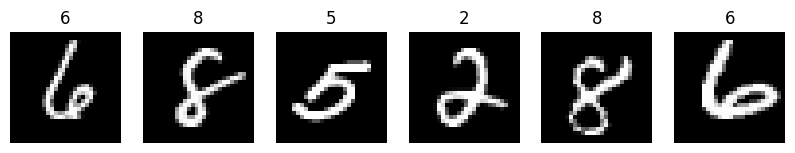

In [3]:
examples = next(iter(train_loader))
images, labels = examples

fig, axes = plt.subplots(1,6, figsize=(10,3))

for i in range(6):
    axes[i].imshow(images[i].squeeze(), cmap="gray")
    axes[i].set_title(str(labels[i].item()))
    axes[i].axis("off")

plt.show()

# Variational Autoencoder Model

## Model Architecture

In [4]:
class VAE(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()


    def encode(self, x):
        h = self.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar


    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z


    def decode(self, z):
        h = self.relu(self.fc3(z))
        return self.sigmoid(self.fc4(h))


    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_reconstructed = self.decode(z)
        return x_reconstructed, mu, logvar

- The Variational Autoencoder (VAE) model consists of an encoder and a decoder network.
- The encoder converts the input image into latent space parameters: mean and log variance.
- The decoder reconstructs the original image from the sampled latent vector z.

## Model Initialization

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAE().to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)

VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=784, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


- The VAE model was initialized with an input dimension of 784, hidden dimension of 400, and latent dimension of 20.
- The model uses ReLU activation in hidden layers and Sigmoid activation in the output layer.
- The Adam optimizer is used to update the model weights during training.

## Loss function

In [6]:
def loss_function(recon_x, x, mu, logvar):

    reconstruction_loss = nn.functional.binary_cross_entropy(
        recon_x, x, reduction="sum"
    )

    kl_divergence = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return reconstruction_loss, kl_divergence

- The VAE uses two loss components: reconstruction loss and KL divergence loss.
- Reconstruction loss measures how accurately the decoder reconstructs the input image.
- KL divergence ensures that the latent space follows a normal distribution for better generalization.

# Training

## Training Loop

In [7]:
epochs = 10

recon_losses = []
kl_losses = []

for epoch in range(epochs):

    total_recon = 0
    total_kl = 0

    for images, _ in train_loader:

        images = images.view(-1, 784).to(device)

        optimizer.zero_grad()

        recon_images, mu, logvar = model(images)

        recon_loss, kl_loss = loss_function(recon_images, images, mu, logvar)

        loss = recon_loss + kl_loss

        loss.backward()
        optimizer.step()

        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    avg_recon = total_recon / len(train_dataset)
    avg_kl = total_kl / len(train_dataset)

    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    print(f"Epoch {epoch+1}")
    print("Reconstruction Loss:", avg_recon)
    print("KL Divergence Loss:", avg_kl)
    print()

Epoch 1
Reconstruction Loss: 149.41989537760418
KL Divergence Loss: 15.294611259094873

Epoch 2
Reconstruction Loss: 99.386401171875
KL Divergence Loss: 22.042494441731773

Epoch 3
Reconstruction Loss: 90.78896476236979
KL Divergence Loss: 23.631402986653647

Epoch 4
Reconstruction Loss: 87.24384593912761
KL Divergence Loss: 24.300060970052083

Epoch 5
Reconstruction Loss: 85.2321342936198
KL Divergence Loss: 24.543536340332032

Epoch 6
Reconstruction Loss: 83.85364436035157
KL Divergence Loss: 24.731969177246093

Epoch 7
Reconstruction Loss: 82.91407688802083
KL Divergence Loss: 24.865551298014324

Epoch 8
Reconstruction Loss: 82.16656299641927
KL Divergence Loss: 24.93884432779948

Epoch 9
Reconstruction Loss: 81.61229287109374
KL Divergence Loss: 25.016469189453126

Epoch 10
Reconstruction Loss: 81.10062263997396
KL Divergence Loss: 25.043806681315104



- The reconstruction loss decreases steadily from about 149 to around 81, showing that the model is learning to reconstruct images better.
- The KL divergence loss increases initially and then stabilizes around 25.
- This indicates that the model is balancing reconstruction accuracy and latent space regularization.

# Visualizations

## Visualizing reconstruction results

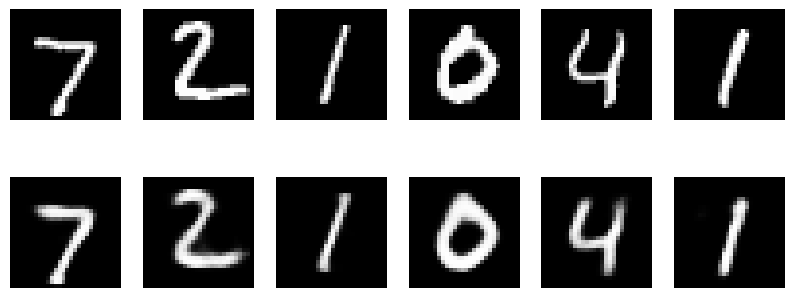

In [9]:
model.eval()

images, _ = next(iter(test_loader))
images = images.view(-1,784).to(device)

with torch.no_grad():
    recon_images, _, _ = model(images)

images = images.cpu().view(-1,1,28,28)
recon_images = recon_images.cpu().view(-1,1,28,28)

fig, axes = plt.subplots(2,6, figsize=(10,4))

for i in range(6):
    axes[0,i].imshow(images[i].squeeze(), cmap="gray")
    axes[0,i].axis("off")

    axes[1,i].imshow(recon_images[i].squeeze(), cmap="gray")
    axes[1,i].axis("off")

axes[0,0].set_ylabel("Original")
axes[1,0].set_ylabel("Reconstructed")

plt.show()

- The reconstructed images closely resemble the original handwritten digits.
- This indicates that the VAE successfully learned meaningful latent representations of the input data.
- Minor blurring occurs because VAEs generate probabilistic reconstructions.

## Latent space visualization

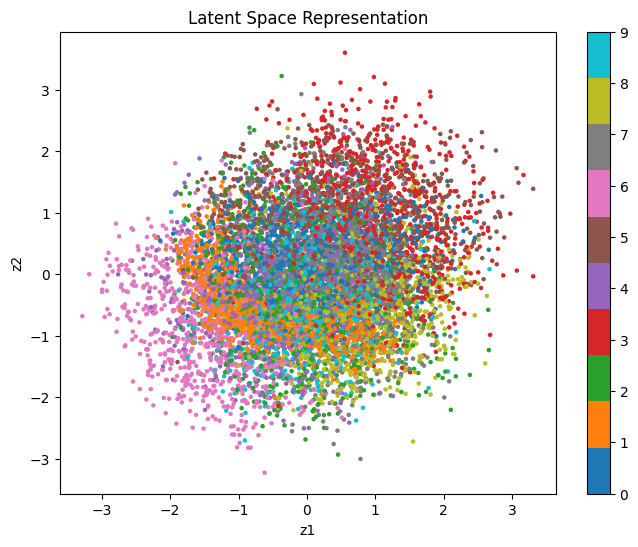

In [8]:
model.eval()

latent_vectors = []
labels_list = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.view(-1,784).to(device)

        mu, logvar = model.encode(images)

        latent_vectors.append(mu.cpu())
        labels_list.append(labels)

latent_vectors = torch.cat(latent_vectors)
labels_list = torch.cat(labels_list)

plt.figure(figsize=(8,6))
plt.scatter(
    latent_vectors[:,0],
    latent_vectors[:,1],
    c=labels_list,
    cmap="tab10",
    s=5
)

plt.colorbar()
plt.title("Latent Space Representation")
plt.xlabel("z1")
plt.ylabel("z2")

plt.show()

- The latent space plot shows the distribution of digit representations in a 2D latent space.
- Points with similar colors (digits) tend to form clusters, indicating that the model learned meaningful features.
- This demonstrates that the VAE organizes similar digit representations close to each other in latent space.